# `dpuct` — max-seeking tree search

Classic MCTS backs up the **mean** return of a subtree. That is exactly right for games but not efficeint for discovery. Under a mean backup, a branch containing one brilliant result and nine failures looks *worse* than a branch of nine
mediocre ones — so the search walks away from the brilliant result.

`dpuct` changes three things:

| | classic PUCT | D-PUCT |
|---|---|---|
| **backup** | subtree mean | subtree **max** `W_m(s)` |
| **prior** | softmax over *sibling* values | softmax over **archive-wide** ranks |
| **actions** | descend into a child | descend, **or sample one more child here** |


---
## Configuration reference

| parameter | symbol | what it does |
|---|---|---|
| `n_select` | n | targets returned per round |
| `k_children` | k | children when a leaf is selected (virtual always gives 1) |
| `c_puct` | c | **explore/exploit dial — tune this first.** 0 = greedy on `W_m` |
| `alpha` | α | 1.0 = ranks only, 0.0 = comparisons only |
| `lambda_virtual` | λ | optimism of the virtual child; 0 = no credit for variance |
| `tau` | τ | prior temperature; small = peaked, large = flat |
| `normalize_exploitation` | | rescale `W_m` to [0,1] so `c` transfers across problems |
| `virtual_value_mode` | | `zero` (prior+bonus only) or `parent_mean` |
| `selection_mode` | | `node` (one target per node) or `action_descend` (MCTS-style descent) |
| `max_archive_size` | | cap on stored nodes; 0 = unbounded |




-----
-----

## Setup

Only `numpy` is required. From this directory:

```bash
pip install -e .          # or: pip install numpy
```

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # run from notebooks/ without installing

import numpy as np
from dpuct import DPUCT, DPUCTConfig, Tree, search

print('ready')

ready


---
## 1. The tree

A node holds a scalar `value` (**higher is better**) and an arbitrary `payload` the library never
inspects which is your board state, program, or anything else.

Now build a tree with two branches: one branch with a buried gem, one flat branch.

In [2]:
tree = Tree()
root = tree.add_root(payload='start')

# Branch A: nine failures and one exceptional result.
branch_a = tree.add_child(root.id, value=0.1, payload='A')
for _ in range(9):
    tree.add_child(branch_a.id, value=0.0)
tree.add_child(branch_a.id, value=9.0, payload='the gem')

# Branch B: consistently mediocre.
branch_b = tree.add_child(root.id, value=1.0, payload='B')
for _ in range(10):
    tree.add_child(branch_b.id, value=1.0)

tree.recompute()      # refreshes m_s and W_m(s) bottom-up

mean_a = np.mean([c.value for c in tree.children(branch_a.id)])
mean_b = np.mean([c.value for c in tree.children(branch_b.id)])

print(f'branch A   mean of children = {mean_a:.2f}   W_m = {tree.get(branch_a.id).subtree_max:.2f}')
print(f'branch B   mean of children = {mean_b:.2f}   W_m = {tree.get(branch_b.id).subtree_max:.2f}')
print()
print('by mean  -> B looks better' if mean_b > mean_a else 'by mean  -> A looks better')
print('by W_m   -> A looks better' if tree.get(branch_a.id).subtree_max > tree.get(branch_b.id).subtree_max else 'by W_m   -> B looks better')

branch A   mean of children = 0.90   W_m = 9.00
branch B   mean of children = 1.00   W_m = 1.00

by mean  -> B looks better
by W_m   -> A looks better


A mean-backup search abandons branch A — the one that
already produced a 9.0 — because its average is dragged down by the failures it is allowed to discard.

---
## 2. The global prior

Classic PUCT builds its prior from **sibling** values. That flatters a node in weak company: mediocre
among mediocre still looks good locally.

D-PUCT instead ranks every node against the **whole archive**, standardizes, and uses that. Ranks rather
than raw values, so the signal does not care about your reward scale or outliers.

In [3]:
policy = DPUCT(DPUCTConfig(alpha=1.0))   # alpha=1.0 -> rank signal only
logits = policy.global_logits(tree)

print(f'L_D(branch A) = {logits[branch_a.id]:+.3f}')
print(f'L_D(branch B) = {logits[branch_b.id]:+.3f}')
print()

L_D(branch A) = +1.754
L_D(branch B) = +0.614



---
## 3. The virtual child 

Standard MCTS has to answer *which existing child do I descend into?* It has no principled way to ask
*should I generate a completely new child here instead?*

D-PUCT adds that as an explicit action, priced at

$$L_p(\hat{s}) = \mu_L(p) + \lambda\,\sigma_L(p)$$

the mean logit of the existing children **plus λ standard deviations**.

The `σ` term is the point. High variance among a parent's children means sampling from that parent is
unpredictable — and when you keep only the best result, **unpredictable is good**. A parent that produced
{0.0, 0.1, 9.0} is a better bet for one more sample than one that produced {1.0, 1.0, 1.0}, even though
the second has a higher mean.

In [4]:
def virtual_logit(child_values, lam=1.0):
    t = Tree()
    r = t.add_root()
    for v in child_values:
        t.add_child(r.id, value=v)
    t.recompute()
    p = DPUCT(DPUCTConfig(lambda_virtual=lam, alpha=1.0))
    pp = p.parent_priors(t, p.global_logits(t))[r.id]
    return pp.mu, pp.sigma, pp.logits['__virtual__']

for label, values in [('consistent  {1,1,1,1}', [1, 1, 1, 1]),
                      ('varied      {0,0,1,9}', [0, 0, 1, 9])]:
    mu, sigma, virt = virtual_logit(values)
    print(f'{label}:  mu={mu:+.3f}  sigma={sigma:.3f}  ->  L(virtual)={virt:+.3f}')

print()
print('lambda controls how much that spread is worth:')
for lam in (0.0, 0.5, 1.0, 2.0):
    _, _, virt = virtual_logit([0, 0, 1, 9], lam=lam)
    print(f'  lambda={lam:<4} -> L(virtual) = {virt:+.3f}')

consistent  {1,1,1,1}:  mu=+0.000  sigma=0.000  ->  L(virtual)=+0.000
varied      {0,0,1,9}:  mu=+0.000  sigma=1.000  ->  L(virtual)=+1.000

lambda controls how much that spread is worth:
  lambda=0.0  -> L(virtual) = +0.000
  lambda=0.5  -> L(virtual) = +0.500
  lambda=1.0  -> L(virtual) = +1.000
  lambda=2.0  -> L(virtual) = +2.000


With `lambda_virtual=0` the unseen sibling is priced at the plain average of its siblings — no optimism.
Raising it makes the search *widen* at parents whose output has been erratic.

---
## 4. Selection

`select()` returns **targets**: places to do work. Two kinds:

- `kind='leaf'` → expand this node into `num_children` children (**deepen**)
- `kind='virtual'` → add exactly one more child to this node (**widen**)

Because a leaf yields `k` and a virtual action yields 1, a round of `n` targets produces between
`n` and `n·k` children.

`explain()` shows the score breakdown, which is the fastest way to see *why* it chose what it chose.

In [5]:
policy = DPUCT(DPUCTConfig(n_select=4, k_children=6, c_puct=1.0, alpha=1.0))
print(policy.explain(tree, limit=8))

print()
targets = policy.select(tree)
for t in targets:
    print(t)
print()
print(f'this round would produce {sum(t.num_children for t in targets)} children',
      f'(bounds: {policy.config.n_select} .. {policy.config.n_select * policy.config.k_children})')

kind     node         x     score         V   prior     bonus
------------------------------------------------------------
virtual  a32b67fc     1    2.0674    0.0000   0.431    2.0674
leaf     39a9fb89     6    1.9905    1.0000   0.597    0.9905
virtual  ed2b125c     1    0.3489    0.0000   0.105    0.3489
virtual  f459181f     1    0.3015    0.0000   0.091    0.3015
leaf     90c2e570     6    0.2619    0.1111   0.091    0.1508
leaf     3825dc76     6    0.2619    0.1111   0.091    0.1508
leaf     cd34a1e0     6    0.2619    0.1111   0.091    0.1508
leaf     53efb5eb     6    0.2619    0.1111   0.091    0.1508

Target(virtual, node=a32b67fc, x1, score=2.0674 = V 0.0000 + bonus 2.0674)
Target(leaf, node=39a9fb89, x6, score=1.9905 = V 1.0000 + bonus 0.9905)
Target(virtual, node=ed2b125c, x1, score=0.3489 = V 0.0000 + bonus 0.3489)
Target(virtual, node=f459181f, x1, score=0.3015 = V 0.0000 + bonus 0.3015)

this round would produce 9 children (bounds: 4 .. 24)


### The explore/exploit dial

At c = 0 selection is greedy on `W_m`; raising it shifts weight
onto the prior-and-visit-count bonus.

In [6]:
for c in (0.0, 0.5, 2.0):
    p = DPUCT(DPUCTConfig(n_select=3, c_puct=c, alpha=1.0))
    picks = p.select(tree)
    kinds = ', '.join(f"{t.kind}({t.score:.2f})" for t in picks)
    print(f'c_puct={c:<4} -> {kinds}')

c_puct=0.0  -> leaf(1.00), leaf(0.11), leaf(0.11)
c_puct=0.5  -> leaf(1.50), virtual(1.03), leaf(0.19)
c_puct=2.0  -> virtual(4.13), leaf(2.98), virtual(0.70)


---
## 5. Driving a real search

If you already have a search loop, use `select()` as your selection step and stop reading here.

If not, supply an `expand` function and let `search()` drive. Signature:

```python
expand(node, num_children) -> [(value, payload), ...]
```

Here we maximize the (negated) **Rastrigin** function — deliberately full of local optima, so a search
that commits to its starting basin fails. Each node holds a point; expanding perturbs it, with the step
shrinking as the tree deepens.

In [7]:
import math, random

def rastrigin(p):
    return -sum(x*x - 10*math.cos(2*math.pi*x) + 10 for x in p)

rng = random.Random(0)
SPAN = 5.12

def expand(node, num_children):
    base = node.payload if node.payload is not None else [0.0, 0.0]
    step = SPAN / (2 ** min(node.depth, 8))      # coarse near the root, fine below
    out = []
    for _ in range(num_children):
        child = [max(-SPAN, min(SPAN, x + rng.gauss(0, step))) for x in base]
        out.append((rastrigin(child), child))
    return out

start = [rng.uniform(-SPAN, SPAN) for _ in range(2)]
result = search(expand, rounds=25,
                config=DPUCTConfig(n_select=4, k_children=6, c_puct=0.7,
                                   alpha=1.0, max_archive_size=2000),
                root_payload=start)

print(f'started at f = {rastrigin(start):9.4f}  {np.round(start, 3)}')
print(f'found      f = {result.best_value:9.4f}  {np.round(result.best_payload, 3)}')
print(f'optimum    f =    0.0000  [0. 0.]')
print(result.tree.summary())

started at f =  -55.5775  [3.527 2.641]
found      f =   -0.0089  [ 0.004 -0.005]
optimum    f =    0.0000  [0. 0.]
{'nodes': 383, 'roots': 1, 'leaves': 326, 'max_depth': 11, 'best_value': -0.008935807852688882}


round   0  targets=  1 (1L/0V) children=   6 |D|=    7 best=-33.802243
round   5  targets=  4 (3L/1V) children=  19 |D|=  107 best=-0.808562
round  10  targets=  4 (2L/2V) children=  14 |D|=  187 best=-0.086039
round  15  targets=  4 (1L/3V) children=   9 |D|=  252 best=-0.021718
round  20  targets=  4 (2L/2V) children=  14 |D|=  327 best=-0.009011


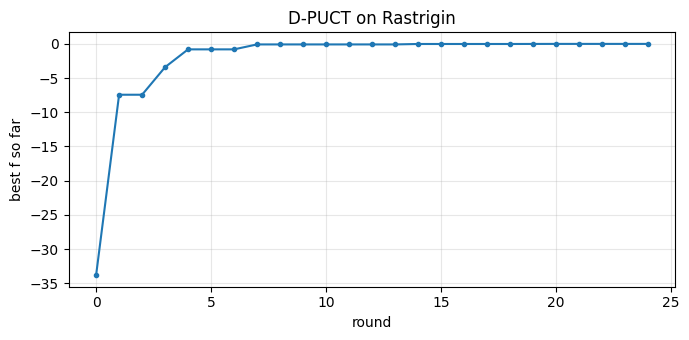

In [8]:
# The best-so-far curve is monotone by construction: you keep the best.
for s in result.history[::5]:
    print(s)

try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(7, 3.5))
    plt.plot(result.curve(), marker='o', ms=3)
    plt.xlabel('round'); plt.ylabel('best f so far')
    plt.title('D-PUCT on Rastrigin'); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
except ImportError:
    print('\n(install matplotlib to see the curve)')

---
## 6. Drawing the tree

Seeing the tree is how you tell whether `c_puct` is doing what you think. Four renderers, in increasing
order of dependency:

| | needs | good for |
|---|---|---|
| `tree.render()` / `render_text` | nothing | terminals, logs, quick checks |
| `to_mermaid` | nothing | GitHub markdown, many notebook viewers |
| `to_dot` | nothing (graphviz to rasterize) | publication figures |
| `tree.draw()` | matplotlib | exploring a big tree |

Each node shows the three numbers selection is actually computed from:
`Q` (own value), `W` (subtree max), `m` (subtree size). **Watching `W` diverge from `Q` down a branch
is watching the max backup work.**

In [9]:
from dpuct import render_text, to_mermaid, to_dot, path_to_best

# Rebuild the pathological tree from section 1.
demo = Tree()
root_d = demo.add_root(payload='start')
branch = demo.add_child(root_d.id, value=0.1, payload='A')
for _ in range(4):
    demo.add_child(branch.id, value=0.0)
demo.add_child(branch.id, value=9.0, payload='gem')
flat = demo.add_child(root_d.id, value=1.0, payload='B')
demo.add_child(flat.id, value=1.1)
demo.recompute()

demo.show()

@ Q=0 W=9 m=9
|-- o Q=0.1 W=9 m=6
|   |-- o Q=0 W=0 m=1
|   |-- o Q=0 W=0 m=1
|   |-- o Q=0 W=0 m=1
|   |-- o Q=0 W=0 m=1
|   `-- * Q=9 W=9 m=1
`-- o Q=1 W=1.1 m=2
    `-- o Q=1.1 W=1.1 m=1
@ root   * best   > selected   o node


`Q=0.1 W=9` on branch A is the whole library in one line: its own value is 0.1, but the best thing
beneath it is a 9. A mean backup would have shown you 0.9 and moved on.

### Matplotlib

Colour is the node's value, size grows with its subtree, the best node is ringed in red and selected
targets are boxed in orange. This is the one to reach for on a tree with hundreds of nodes.

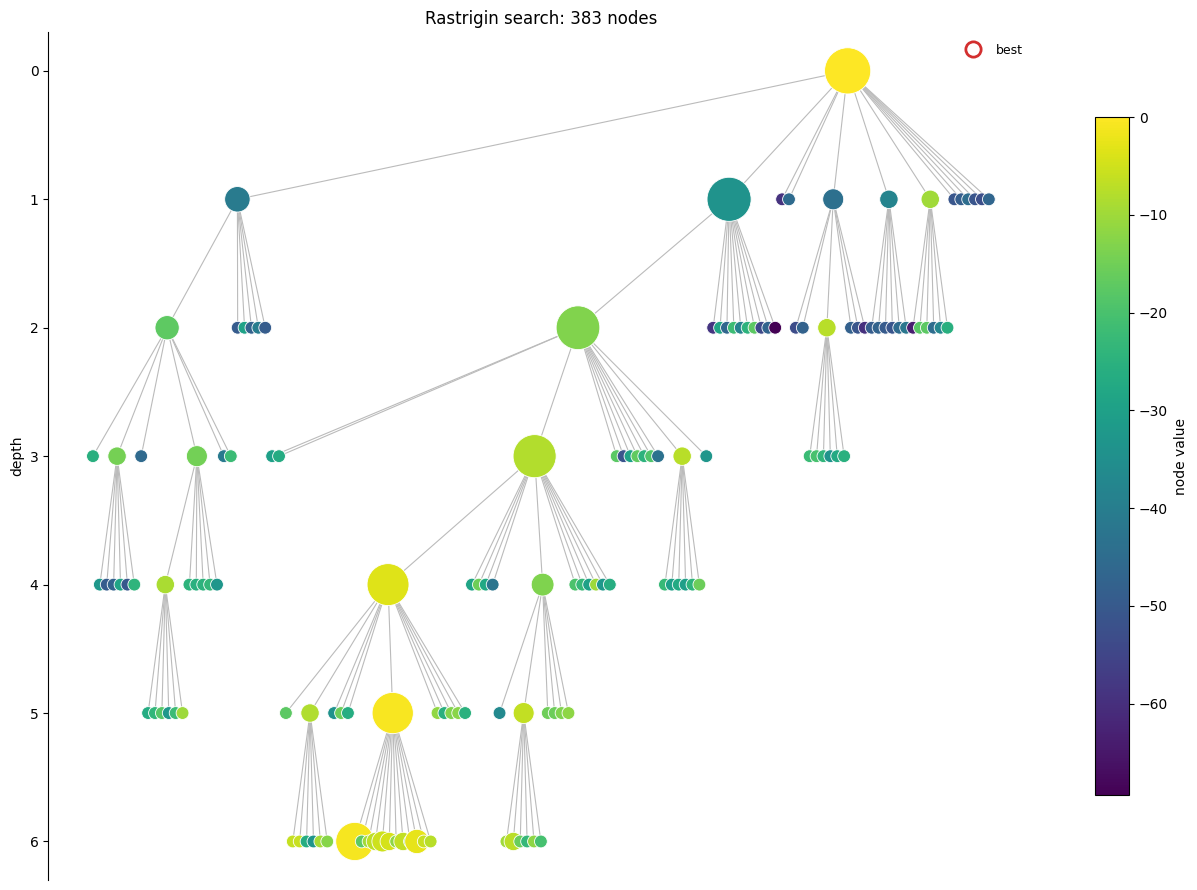

In [16]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 1, figsize=(13, 9))

    # demo.draw(ax=axes[0], targets=picked, annotate=True,
    #           title='small tree: values annotated, selection boxed')
    result.tree.draw(ax=axes, max_depth=6,
                     title=f'Rastrigin search: {len(result.tree)} nodes')
    plt.tight_layout(); plt.show()
except ImportError:
    print('pip install matplotlib to see this one')
    print('(render_text, to_dot and to_mermaid need nothing)')

---
## 7. Plugging into an existing MCTS

The policy is stateless with respect to your tree, so the integration is small. The pattern:

In [11]:
# Sketch: replace your selection step, keep everything else.

my_tree = Tree()
root = my_tree.add_root(payload='initial state')
policy = DPUCT(DPUCTConfig(n_select=2, k_children=3, c_puct=1.0, alpha=1.0))

for round_index in range(3):
    my_tree.recompute()                       # 1. refresh W_m and m_s
    for target in policy.select(my_tree):     # 2. pick where to work
        node = my_tree.get(target.node_id)
        # 3. YOUR code: roll out / call a model / run a simulator
        for i in range(target.num_children):
            value = rng.random()              # <- your evaluation
            my_tree.add_child(node.id, value=value, payload=f'r{round_index}c{i}')

my_tree.recompute()
print(my_tree.summary())
print('best payload:', my_tree.best().payload)

{'nodes': 14, 'roots': 1, 'leaves': 10, 'max_depth': 3, 'best_value': 0.9344608884461488}
best payload: r2c2


Three rules for the integration:

1. Call `tree.recompute()` **before** `select()` — the statistics are not maintained incrementally.
2. `value` is always **higher-is-better**. Minimizing? Store the negation.
3. Honour `target.num_children`: `k` for a leaf, exactly 1 for a virtual action. Returning fewer is fine.

That is the whole contract.